In [3]:
import requests
import pandas as pd
from pathlib import Path

# ============================================
# ПАПКА ДЛЯ СОХРАНЕНИЯ
# ============================================

DATA_DIR = Path("data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# ============================================
# ПАРАМЕТРЫ
# ============================================

START_DATE = "2008-01-01"
END_DATE = "2026-01-01"

# ============================================
# СПИСОК ИНСТРУМЕНТОВ
# ============================================

MOEX_SYMBOLS = {
    # Валюты
    "usd_rub": {
        "engine": "currency",
        "market": "selt",
        "security": "USD000UTSTOM",
    },
    "eur_rub": {
        "engine": "currency",
        "market": "selt",
        "security": "EUR_RUB__TOM",
    },

    # Индексы
    "imoex": {
        "engine": "stock",
        "market": "index",
        "security": "IMOEX",
    },

    "rtsi": {
        "engine": "stock",
        "market": "index",
        "security": "RTSI",
    },
}

# ============================================
# ФУНКЦИЯ ЗАГРУЗКИ
# ============================================

def load_moex_history(engine, market, security,
                      start_date, end_date):

    start = 0
    all_rows = []

    while True:

        url = (
            f"https://iss.moex.com/iss/history/"
            f"engines/{engine}/markets/{market}/"
            f"securities/{security}.json"
        )

        params = {
            "from": start_date,
            "till": end_date,
            "start": start,
        }

        response = requests.get(url, params=params)

        if response.status_code != 200:
            print(f"Ошибка загрузки {security}")
            break

        data = response.json()

        history = data.get("history", {})

        columns = history.get("columns", [])
        rows = history.get("data", [])

        if not rows:
            break

        df_part = pd.DataFrame(rows, columns=columns)

        all_rows.append(df_part)

        start += 100

    if not all_rows:
        return None

    df = pd.concat(all_rows, ignore_index=True)

    return df


# ============================================
# СКАЧИВАНИЕ ВСЕХ ДАННЫХ
# ============================================

all_data = {}

for name, params in MOEX_SYMBOLS.items():

    print(f"\nСкачиваем {name}...")

    df = load_moex_history(
        engine=params["engine"],
        market=params["market"],
        security=params["security"],
        start_date=START_DATE,
        end_date=END_DATE,
    )

    if df is not None:

        # ====================================
        # БАЗОВАЯ ОЧИСТКА
        # ====================================

        if "TRADEDATE" in df.columns:
            df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])

        df = df.sort_values("TRADEDATE")

        # ====================================
        # СОХРАНЕНИЕ CSV
        # ====================================

        save_path = DATA_DIR / f"{name}.csv"

        df.to_csv(save_path, index=False)

        print(f"Сохранено: {save_path}")

        all_data[name] = df

# ============================================
# ПРИМЕР ПРОСМОТРА
# ============================================

print("\nГотово!")

for name, df in all_data.items():
    print(f"{name}: {df.shape}")


Скачиваем usd_rub...


/var/folders/22/xgbcd1m54tb5vr22dh3t9prr0000gn/T/ipykernel_64951/1405431901.py:99: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(all_rows, ignore_index=True)


Сохранено: data/raw/usd_rub.csv

Скачиваем eur_rub...


/var/folders/22/xgbcd1m54tb5vr22dh3t9prr0000gn/T/ipykernel_64951/1405431901.py:99: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(all_rows, ignore_index=True)


Сохранено: data/raw/eur_rub.csv

Скачиваем imoex...


/var/folders/22/xgbcd1m54tb5vr22dh3t9prr0000gn/T/ipykernel_64951/1405431901.py:99: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(all_rows, ignore_index=True)


Сохранено: data/raw/imoex.csv

Скачиваем rtsi...
Сохранено: data/raw/rtsi.csv

Готово!
usd_rub: (12569, 10)
eur_rub: (12569, 10)
imoex: (4514, 20)
rtsi: (4511, 20)


/var/folders/22/xgbcd1m54tb5vr22dh3t9prr0000gn/T/ipykernel_64951/1405431901.py:99: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(all_rows, ignore_index=True)


In [2]:
import pandas as pd

In [34]:
usd = pd.read_csv('raw/usd_rub.csv')
eur = pd.read_csv('raw/eur_rub.csv')
rtsi = pd.read_csv('raw/rtsi.csv')
imoex = pd.read_csv('raw/imoex.csv')


In [35]:
# Только основной режим торгов
usd = usd[usd["BOARDID"] == "CETS"]

# Удаляем пустые строки
usd = usd[usd["CLOSE"] != 0]

# Удаляем NaN
usd = usd.dropna(subset=["CLOSE"])

# Дата
usd["TRADEDATE"] = pd.to_datetime(usd["TRADEDATE"])

# Сортировка
usd = usd.sort_values("TRADEDATE")

# Оставляем нужные колонки
usd = usd[
    [
        "TRADEDATE",
        "OPEN",
        "LOW",
        "HIGH",
        "CLOSE",
        "NUMTRADES",
    ]
]

In [37]:
import yfinance as yf 

In [42]:
from pathlib import Path

SAVE_DIR = Path("data/yahoo")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

TICKERS = {
    "gold": "GC=F",
    "brent": "BZ=F",
    "usd_rub": "RUB=X",
    "eur_rub": "EURRUB=X",
    "imoex": "IMOEX.ME",
    "vix": "^VIX",
    "sp500": "^GSPC",
}


for name, ticker in TICKERS.items():

    print(f"Скачиваем {name}...")

    df = yf.download(
        ticker,
        start="2008-01-01",
        end="2026-01-01",
        auto_adjust=False
    )

    df.reset_index(inplace=True)

    save_path = SAVE_DIR / f"{name}.csv"

    df.to_csv(save_path, index=False)

    print(f"Сохранено: {save_path}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Скачиваем gold...
Сохранено: data/yahoo/gold.csv
Скачиваем brent...
Сохранено: data/yahoo/brent.csv
Скачиваем usd_rub...



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Сохранено: data/yahoo/usd_rub.csv
Скачиваем eur_rub...
Сохранено: data/yahoo/eur_rub.csv
Скачиваем imoex...
Сохранено: data/yahoo/imoex.csv
Скачиваем vix...
Сохранено: data/yahoo/vix.csv
Скачиваем sp500...


Сохранено: data/yahoo/sp500.csv


In [69]:
brent = pd.read_csv('data/yahoo/brent.csv')
eur_rub = pd.read_csv('/Users/mila/Desktop/ИВР/data/yahoo/eur_rub.csv')
gold = pd.read_csv('/Users/mila/Desktop/ИВР/data/yahoo/gold.csv')
imoex = pd.read_csv('/Users/mila/Desktop/ИВР/data/yahoo/imoex.csv')
sp500 = pd.read_csv('/Users/mila/Desktop/ИВР/data/yahoo/sp500.csv')
usd_rub = pd.read_csv('/Users/mila/Desktop/ИВР/data/yahoo/usd_rub.csv')
vix = pd.read_csv('/Users/mila/Desktop/ИВР/data/yahoo/vix.csv')


In [70]:
display(brent)
display(eur_rub)
display(gold)
display(imoex)
display(sp500)
display(usd_rub)
display(vix)

,Date,Adj Close,Close,High,Low,Open,Volume
0,NaN,BZ=F,BZ=F,BZ=F,BZ=F,BZ=F,BZ=F
1,2008-01-02,97.83999633789062,97.83999633789062,98.0199966430664,94.19999694824219,94.30000305175781,1149
2,2008-01-03,97.5999984741211,97.5999984741211,98.47000122070312,97.06999969482422,97.5,1386
3,2008-01-04,96.79000091552734,96.79000091552734,97.88999938964844,96.20999908447266,97.73999786376953,1240
4,2008-01-07,94.38999938964844,94.38999938964844,97.45999908447266,93.7300033569336,96.81999969482422,1826
...,...,...,...,...,...,...,...
4473,2025-12-24,62.2400016784668,62.2400016784668,62.720001220703125,62.02000045776367,62.43000030517578,14966
4474,2025-12-26,60.63999938964844,60.63999938964844,62.689998626708984,60.59000015258789,62.349998474121094,9687
4475,2025-12-29,61.939998626708984,61.939998626708984,62.150001525878906,60.95000076293945,61.040000915527344,9170
4476,2025-12-30,61.91999816894531,61.91999816894531,62.33000183105469,61.5099983215332,61.70000076293945,30567


,Date,Adj Close,Close,High,Low,Open,Volume
0,NaN,EURRUB=X,EURRUB=X,EURRUB=X,EURRUB=X,EURRUB=X,EURRUB=X
1,2008-01-01,35.29240036010742,35.29240036010742,35.29240036010742,35.29240036010742,35.29240036010742,0
2,2008-01-02,35.25920104980469,35.25920104980469,36.01359939575195,35.887001037597656,35.89390182495117,0
3,2008-01-03,36.013999938964844,36.013999938964844,36.04800033569336,35.25920104980469,35.25920104980469,0
4,2008-01-04,36.025001525878906,36.025001525878906,36.126399993896484,35.943199157714844,36.01499938964844,0
...,...,...,...,...,...,...,...
4683,2025-12-24,91.99459838867188,91.99459838867188,93.12149810791016,91.88259887695312,91.99459838867188,0
4684,2025-12-26,93.01409912109375,93.01409912109375,93.12149810791016,91.88259887695312,93.01409912109375,0
4685,2025-12-29,93.01409912109375,93.01409912109375,92.43379974365234,90.08380126953125,93.01409912109375,0
4686,2025-12-30,92.40689849853516,92.40689849853516,93.88500213623047,91.87909698486328,92.410400390625,0


,Date,Adj Close,Close,High,Low,Open,Volume
0,NaN,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
1,2008-01-02,857.0,857.0,857.7999877929688,846.4000244140625,848.7000122070312,130
2,2008-01-03,866.4000244140625,866.4000244140625,865.5,856.2999877929688,863.0,181
3,2008-01-04,863.0999755859375,863.0999755859375,865.5,860.2000122070312,861.4000244140625,28
4,2008-01-07,859.5999755859375,859.5999755859375,860.9000244140625,857.4000244140625,860.9000244140625,4
...,...,...,...,...,...,...,...
4524,2025-12-24,4480.60009765625,4480.60009765625,4503.39990234375,4468.39990234375,4500.7001953125,500
4525,2025-12-26,4529.10009765625,4529.10009765625,4556.2998046875,4502.0,4512.0,263
4526,2025-12-29,4325.10009765625,4325.10009765625,4379.0,4325.10009765625,4371.5,2044
4527,2025-12-30,4370.10009765625,4370.10009765625,4403.60009765625,4338.0,4346.39990234375,1837


,Date,Adj Close,Close,High,Low,Open,Volume
0,NaN,IMOEX.ME,IMOEX.ME,IMOEX.ME,IMOEX.ME,IMOEX.ME,IMOEX.ME
1,2013-03-05,1486.4200439453125,1486.4200439453125,1486.72998046875,1485.0400390625,1485.0400390625,0
2,2013-03-06,1491.489990234375,1491.489990234375,1498.02001953125,1485.0400390625,1485.0400390625,0
3,2013-03-07,1491.3499755859375,1491.3499755859375,1498.2900390625,1489.02001953125,1491.989990234375,0
4,2013-03-11,1505.9300537109375,1505.9300537109375,1506.4200439453125,1503.6400146484375,1503.97998046875,0
...,...,...,...,...,...,...,...
2791,2024-06-07,3233.219970703125,3233.219970703125,3268.889892578125,3193.570068359375,3199.75,0
2792,2024-06-10,3180.93994140625,3180.93994140625,3255.489990234375,3180.2099609375,3245.39990234375,0
2793,2024-06-11,3171.10009765625,3171.10009765625,3191.27001953125,3148.219970703125,3178.7099609375,0
2794,2024-06-13,3171.68994140625,3171.68994140625,3178.010009765625,3032.050048828125,3050.030029296875,0


,Date,Adj Close,Close,High,Low,Open,Volume
0,NaN,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
1,2008-01-02,1447.1600341796875,1447.1600341796875,1471.77001953125,1442.0699462890625,1467.969970703125,3452650000
2,2008-01-03,1447.1600341796875,1447.1600341796875,1456.800048828125,1443.72998046875,1447.550048828125,3429500000
3,2008-01-04,1411.6300048828125,1411.6300048828125,1444.010009765625,1411.18994140625,1444.010009765625,4166000000
4,2008-01-07,1416.1800537109375,1416.1800537109375,1423.8699951171875,1403.449951171875,1414.0699462890625,4221260000
...,...,...,...,...,...,...,...
4525,2025-12-24,6932.0498046875,6932.0498046875,6937.31982421875,6904.91015625,6904.91015625,1798270000
4526,2025-12-26,6929.93994140625,6929.93994140625,6945.77001953125,6921.60009765625,6936.02001953125,2586550000
4527,2025-12-29,6905.740234375,6905.740234375,6920.2099609375,6888.759765625,6903.60009765625,3541750000
4528,2025-12-30,6896.240234375,6896.240234375,6913.25,6893.47021484375,6900.43994140625,3309930000


,Date,Adj Close,Close,High,Low,Open,Volume
0,NaN,RUB=X,RUB=X,RUB=X,RUB=X,RUB=X,RUB=X
1,2008-01-03,24.429000854492188,24.429000854492188,24.4689998626709,24.4060001373291,24.450000762939453,0
2,2008-01-04,24.413999557495117,24.413999557495117,24.4689998626709,24.367000579833984,24.42799949645996,0
3,2008-01-07,24.415000915527344,24.415000915527344,24.496999740600586,24.42300033569336,24.42300033569336,0
4,2008-01-10,24.354000091552734,24.354000091552734,24.462499618530273,24.33799934387207,24.458999633789062,0
...,...,...,...,...,...,...,...
4660,2025-12-24,77.99622344970703,77.99622344970703,79.00895690917969,77.9770278930664,77.99591064453125,0
4661,2025-12-26,78.9462890625,78.9462890625,79.08924102783203,78.85628509521484,78.95130920410156,0
4662,2025-12-29,79.02978515625,79.02978515625,79.14879608154297,76.49454498291016,79.01937866210938,0
4663,2025-12-30,78.50053405761719,78.50053405761719,79.80572509765625,78.04254913330078,78.49620056152344,0


,Date,Adj Close,Close,High,Low,Open,Volume
0,NaN,^VIX,^VIX,^VIX,^VIX,^VIX,^VIX
1,2008-01-02,23.170000076293945,23.170000076293945,24.049999237060547,22.399999618530273,22.579999923706055,0
2,2008-01-03,22.489999771118164,22.489999771118164,23.270000457763672,22.110000610351562,23.110000610351562,0
3,2008-01-04,23.940000534057617,23.940000534057617,24.299999237060547,23.25,23.5,0
4,2008-01-07,23.790000915527344,23.790000915527344,24.8799991607666,23.299999237060547,24.6200008392334,0
...,...,...,...,...,...,...,...
4525,2025-12-24,13.470000267028809,13.470000267028809,14.15999984741211,13.380000114440918,14.09000015258789,0
4526,2025-12-26,13.600000381469727,13.600000381469727,14.289999961853027,13.520000457763672,14.119999885559082,0
4527,2025-12-29,14.199999809265137,14.199999809265137,15.079999923706055,13.989999771118164,14.6899995803833,0
4528,2025-12-30,14.329999923706055,14.329999923706055,14.619999885559082,14.039999961853027,14.430000305175781,0


In [51]:
ofz_1 = pd.read_csv('data/moex/ofz_1y.csv', sep=';', skiprows=1)
ofz_2 = pd.read_csv('data/moex/ofz_2y.csv', sep=';', skiprows=1)
ofz_5 = pd.read_csv('data/moex/ofz_5y.csv', sep=';', skiprows=1)
ofz_10 = pd.read_csv('data/moex/ofz_10y.csv', sep=';', skiprows=1)

In [66]:
ofz_1

,tradedate,tradetime,period_1.0
0,06.01.2014,12:21:16,"6,19"
1,08.01.2014,12:41:22,"6,19"
2,09.01.2014,18:38:19,"6,07"
3,10.01.2014,18:38:17,"6,02"
4,13.01.2014,18:37:26,"6,07"
...,...,...,...
3098,04.05.2026,18:49:58,"13,04"
3099,05.05.2026,18:49:57,"13,1"
3100,06.05.2026,18:49:58,"13,02"
3101,07.05.2026,18:49:58,"13,08"


In [52]:
display(ofz_1.columns)
display(ofz_2.columns)
display(ofz_5.columns)
display(ofz_10.columns)

Index(['tradedate', 'tradetime', 'period_1.0'], dtype='object')

Index(['tradedate', 'tradetime', 'period_2.0'], dtype='object')

Index(['tradedate', 'tradetime', 'period_5.0'], dtype='object')

Index(['tradedate', 'tradetime', 'period_10.0'], dtype='object')

In [56]:
macro = pd.read_csv('data/inflation_key_rate.csv', sep=';')
macro

,date,key_rate,inflation
0,12.2025,"16,00","5,59"
1,11.2025,"16,50","6,64"
2,10.2025,"16,50","7,71"
3,9.2025,"17,00","7,98"
4,8.2025,"18,00","8,14"
...,...,...,...
139,5.2014,"7,50","7,59"
140,4.2014,"7,50","7,33"
141,3.2014,"7,00","6,92"
142,2.2014,"5,50","6,21"


In [85]:
import pandas as pd
from functools import reduce

START_DATE = "2014-01-01"
END_DATE = "2025-12-31"

# =========================
# HELPERS
# =========================

def to_float_series(s):
    return (
        s.astype(str)
        .str.replace(",", ".", regex=False)
        .replace(["None", "nan", "NaN", ""], pd.NA)
        .astype(float)
    )


def prepare_yahoo(path, name):
    df = pd.read_csv(path)

    # удаляем мусорную строку с тикером: BZ=F, GC=F и т.д.
    df = df[df["Date"].notna()].copy()

    df["date"] = pd.to_datetime(df["Date"], errors="coerce").dt.normalize()
    df[name] = pd.to_numeric(df["Close"], errors="coerce")

    df = df[["date", name]]
    df = df.dropna(subset=["date"])
    df = df.groupby("date", as_index=False).last()

    return df


def prepare_ofz(path, period_col, new_name):
    df = pd.read_csv(path, sep=";", skiprows=1)

    df["date"] = pd.to_datetime(
        df["tradedate"],
        dayfirst=True,
        errors="coerce"
    ).dt.normalize()

    df[new_name] = to_float_series(df[period_col])

    df = df[["date", new_name]]
    df = df.dropna(subset=["date"])
    df = df.groupby("date", as_index=False).last()

    return df


def prepare_macro(path):

    df = pd.read_csv(path, sep=";")

    df["date"] = (
        df["date"]
        .astype(str)
        .str.strip()
    )

    df["date"] = pd.to_datetime(
        "01." + df["date"],
        format="%d.%m.%Y",
        errors="coerce"
    ).dt.normalize()

    df["key_rate"] = (
        df["key_rate"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

    df["inflation"] = (
        df["inflation"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

    df = df[[
        "date",
        "key_rate",
        "inflation"
    ]]

    df = df.dropna(subset=["date"])

    df = (
        df
        .sort_values("date")
        .groupby("date", as_index=False)
        .last()
    )

    return df


# =========================
# LOAD DATA
# =========================

gold = prepare_yahoo("data/yahoo/gold.csv", "gold")
brent = prepare_yahoo("data/yahoo/brent.csv", "brent")
usd = prepare_yahoo("data/yahoo/usd_rub.csv", "usd_rub")
eur = prepare_yahoo("data/yahoo/eur_rub.csv", "eur_rub")
imoex = prepare_yahoo("data/yahoo/imoex.csv", "imoex")
vix = prepare_yahoo("data/yahoo/vix.csv", "vix")
sp500 = prepare_yahoo("data/yahoo/sp500.csv", "sp500")

ofz_1y = prepare_ofz("data/moex/ofz_1y.csv", "period_1.0", "ofz_1y")
ofz_2y = prepare_ofz("data/moex/ofz_2y.csv", "period_2.0", "ofz_2y")
ofz_5y = prepare_ofz("data/moex/ofz_5y.csv", "period_5.0", "ofz_5y")
ofz_10y = prepare_ofz("data/moex/ofz_10y.csv", "period_10.0", "ofz_10y")

macro = prepare_macro("data/inflation_key_rate.csv")


# =========================
# MERGE
# =========================

dfs = [
    gold,
    brent,
    usd,
    eur,
    imoex,
    vix,
    sp500,
    ofz_1y,
    ofz_2y,
    ofz_5y,
    ofz_10y,
    macro
]

df = reduce(
    lambda left, right: pd.merge(left, right, on="date", how="outer"),
    dfs
)

df = df.sort_values("date")
df = df.groupby("date", as_index=False).last()

# ограничиваем нормальный период
df = df[
    (df["date"] >= START_DATE) &
    (df["date"] <= END_DATE)
].copy()

# делаем daily сетку
full_dates = pd.date_range(START_DATE, END_DATE, freq="D")

df = (
    df.set_index("date")
    .reindex(full_dates)
    .rename_axis("date")
    .reset_index()
)

# forward fill — норм для dashboard:
# рыночные данные на выходных = последнее доступное значение
# macro monthly = последнее известное значение
df = df.ffill()


# =========================
# FEATURES
# =========================

df["ofz_spread_10_2"] = df["ofz_10y"] - df["ofz_2y"]

df["usd_volatility"] = (
    df["usd_rub"]
    .pct_change()
    .rolling(30)
    .std()
)

df["imoex_volatility"] = (
    df["imoex"]
    .pct_change()
    .rolling(30)
    .std()
)

df["imoex_drawdown"] = (
    df["imoex"] / df["imoex"].cummax() - 1
)

df["imoex_zscore"] = (
    df["imoex"] - df["imoex"].rolling(30).mean()
) / df["imoex"].rolling(30).std()

df["real_key_rate"] = df["key_rate"] - df["inflation"]


# =========================
# SAVE
# =========================

df.to_csv("data/final_dataset.csv", index=False)

display(df.head())
display(df.tail())
display(df.isna().sum())
display(df.shape)

,date,gold,brent,usd_rub,eur_rub,imoex,vix,sp500,ofz_1y,ofz_2y,ofz_5y,ofz_10y,key_rate,inflation,ofz_spread_10_2,usd_volatility,imoex_volatility,imoex_drawdown,imoex_zscore,real_key_rate
0,2014-01-01,NaN,NaN,32.683201,45.213001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.5,6.07,NaN,NaN,NaN,NaN,NaN,-0.57
1,2014-01-02,1225.000000,107.779999,32.706001,45.213001,NaN,14.23,1831.979980,NaN,NaN,NaN,NaN,5.5,6.07,NaN,NaN,NaN,NaN,NaN,-0.57
2,2014-01-03,1238.400024,106.889999,33.095200,45.194099,NaN,13.76,1831.369995,NaN,NaN,NaN,NaN,5.5,6.07,NaN,NaN,NaN,NaN,NaN,-0.57
3,2014-01-04,1238.400024,106.889999,33.095200,45.194099,NaN,13.76,1831.369995,NaN,NaN,NaN,NaN,5.5,6.07,NaN,NaN,NaN,NaN,NaN,-0.57
4,2014-01-05,1238.400024,106.889999,33.095200,45.194099,NaN,13.76,1831.369995,NaN,NaN,NaN,NaN,5.5,6.07,NaN,NaN,NaN,NaN,NaN,-0.57


,date,gold,brent,usd_rub,eur_rub,imoex,vix,sp500,ofz_1y,ofz_2y,ofz_5y,ofz_10y,key_rate,inflation,ofz_spread_10_2,usd_volatility,imoex_volatility,imoex_drawdown,imoex_zscore,real_key_rate
4378,2025-12-27,4529.100098,60.639999,78.946289,93.014099,3215.909912,13.60,6929.939941,13.66,14.34,14.80,14.44,16.0,5.59,0.10,0.009152,0.0,-0.249937,NaN,10.41
4379,2025-12-28,4529.100098,60.639999,78.946289,93.014099,3215.909912,13.60,6929.939941,13.66,14.34,14.80,14.44,16.0,5.59,0.10,0.009051,0.0,-0.249937,NaN,10.41
4380,2025-12-29,4325.100098,61.939999,79.029785,93.014099,3215.909912,14.20,6905.740234,13.60,14.25,14.72,14.44,16.0,5.59,0.19,0.009051,0.0,-0.249937,NaN,10.41
4381,2025-12-30,4370.100098,61.919998,78.500534,92.406898,3215.909912,14.33,6896.240234,13.14,13.92,14.58,14.44,16.0,5.59,0.52,0.009146,0.0,-0.249937,NaN,10.41
4382,2025-12-31,4325.600098,60.849998,79.496201,93.381401,3215.909912,14.95,6845.500000,13.14,13.92,14.58,14.44,16.0,5.59,0.52,0.008992,0.0,-0.249937,NaN,10.41


date                  0
gold                  1
brent                 1
usd_rub               0
eur_rub               0
imoex                 5
vix                   1
sp500                 1
ofz_1y                5
ofz_2y                5
ofz_5y                5
ofz_10y               5
key_rate              0
inflation             0
ofz_spread_10_2       5
usd_volatility       30
imoex_volatility     35
imoex_drawdown        5
imoex_zscore        571
real_key_rate         0
dtype: int64

(4383, 20)

In [86]:
df.sample(10)

,date,gold,brent,usd_rub,eur_rub,imoex,vix,sp500,ofz_1y,ofz_2y,ofz_5y,ofz_10y,key_rate,inflation,ofz_spread_10_2,usd_volatility,imoex_volatility,imoex_drawdown,imoex_zscore,real_key_rate
3412,2023-05-06,2017.400024,75.300003,78.464996,86.691399,2538.239990,17.190001,4136.250000,7.40,7.93,9.55,10.89,7.50,2.51,2.96,0.006534,0.007714,-0.407993,-0.915444,4.99
2840,2021-10-11,1754.599976,83.650002,71.753304,82.993698,4279.870117,20.000000,4361.189941,7.32,7.38,7.43,7.58,7.50,8.13,0.20,0.003550,0.008310,0.000000,2.198492,-0.63
1619,2018-06-08,1298.099976,76.459999,62.341499,73.552902,2267.919922,12.180000,2779.030029,6.72,6.84,7.19,7.64,7.25,2.30,0.80,0.007012,0.006502,-0.038047,-2.409460,4.95
1564,2018-04-14,1344.800049,72.580002,62.016300,76.499802,2175.159912,17.410000,2656.300049,6.85,6.94,7.17,7.55,7.25,2.40,0.61,0.011377,0.018084,-0.075643,-1.724678,4.85
2705,2021-05-29,1902.500000,69.629997,73.440201,89.583801,3730.550049,16.760000,4204.109863,5.86,6.10,6.73,7.24,5.00,6.00,1.14,0.003916,0.006507,-0.002175,1.495033,-1.00
3745,2024-04-03,2294.399902,89.349998,92.279999,99.567497,3395.590088,14.330000,5211.490234,14.44,13.81,13.04,13.30,16.00,7.84,-0.51,0.005048,0.003860,-0.208029,2.818939,8.16
806,2016-03-17,1264.500000,41.540001,69.834999,77.373947,1890.790039,14.440000,2040.589966,9.41,9.23,9.14,9.10,11.00,7.30,-0.13,0.012276,0.008636,-0.009835,1.168155,3.70
4197,2025-06-29,3273.699951,67.769997,78.748581,92.064903,3215.909912,16.320000,6173.069824,15.58,14.73,14.60,14.85,20.00,9.40,0.12,0.008716,0.000000,-0.249937,NaN,10.60
3298,2023-01-12,1895.500000,84.029999,69.119003,75.680496,2185.929932,18.830000,3983.169922,7.39,7.97,9.41,10.39,7.50,11.77,2.42,0.027255,0.005047,-0.490164,2.041295,-4.27
2651,2021-04-05,1727.000000,62.150002,76.415199,89.799599,3524.929932,17.910000,4077.909912,5.14,5.71,6.78,7.27,5.00,5.50,1.56,0.005952,0.008282,-0.018079,0.524359,-0.50


In [74]:
macro = prepare_macro("data/inflation_key_rate.csv")
display(macro.head())
display(macro.tail())
display(macro.dtypes)

,date,key_rate,inflation


,date,key_rate,inflation


date         datetime64[ns]
key_rate            float64
inflation           float64
dtype: object

In [83]:
ggg = pd.read_csv('/Users/mila/Desktop/ИВР/data/inflation_key_rate.csv', sep=';')
ggg

,date,key_rate,inflation
0,12.2025,"16,00","5,59"
1,11.2025,"16,50","6,64"
2,10.2025,"16,50","7,71"
3,9.2025,"17,00","7,98"
4,8.2025,"18,00","8,14"
...,...,...,...
139,5.2014,"7,50","7,59"
140,4.2014,"7,50","7,33"
141,3.2014,"7,00","6,92"
142,2.2014,"5,50","6,21"


In [84]:
ggg["date"] = (
    ggg["date"]
    .astype(str)
    .str.strip()
)

ggg["date"] = pd.to_datetime(
    "01." + ggg["date"],
    format="%d.%m.%Y",
    errors="coerce"
).dt.normalize()

ggg["key_rate"] = (
    ggg["key_rate"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

ggg["inflation"] = (
    ggg["inflation"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

display(ggg.head())
display(ggg.tail())

,date,key_rate,inflation
0,2025-12-01,16.0,5.59
1,2025-11-01,16.5,6.64
2,2025-10-01,16.5,7.71
3,2025-09-01,17.0,7.98
4,2025-08-01,18.0,8.14


,date,key_rate,inflation
139,2014-05-01,7.5,7.59
140,2014-04-01,7.5,7.33
141,2014-03-01,7.0,6.92
142,2014-02-01,5.5,6.21
143,2014-01-01,5.5,6.07


In [82]:
ggg["date"] = pd.to_datetime(
        ggg["date"],
        format="%m.%Y",
        errors="coerce"
    ).dt.normalize()

In [80]:
ggg

,date,key_rate,inflation
0,NaT,"16,00","5,59"
1,NaT,"16,50","6,64"
2,NaT,"16,50","7,71"
3,NaT,"17,00","7,98"
4,NaT,"18,00","8,14"
...,...,...,...
139,NaT,"7,50","7,59"
140,NaT,"7,50","7,33"
141,NaT,"7,00","6,92"
142,NaT,"5,50","6,21"


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('/Users/mila/Desktop/ИВР/data/final_dataset.csv')

In [5]:
df

,date,gold,brent,usd_rub,eur_rub,imoex,vix,sp500,ofz_1y,ofz_2y,ofz_5y,ofz_10y,key_rate,inflation,ofz_spread_10_2,usd_volatility,imoex_volatility,imoex_drawdown,imoex_zscore,real_key_rate
0,2014-01-01,NaN,NaN,32.6587,45.0559,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-01-02,1225.000000,107.779999,32.6587,45.0559,NaN,14.230000,1831.979980,NaN,NaN,NaN,NaN,5.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-01-03,1238.400024,106.889999,32.6587,45.0559,NaN,13.760000,1831.369995,NaN,NaN,NaN,NaN,5.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-01-04,1238.400024,106.889999,32.6587,45.0559,NaN,13.760000,1831.369995,NaN,NaN,NaN,NaN,5.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-01-05,1238.400024,106.889999,32.6587,45.0559,NaN,13.760000,1831.369995,NaN,NaN,NaN,NaN,5.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4512,2026-05-10,4720.399902,101.290001,74.2963,88.5490,2597.80,17.190001,7398.930176,13.03,13.39,14.32,14.69,14.5,5.59,1.3,0.005672,0.006887,-0.394102,-1.308487,8.91
4513,2026-05-11,4718.700195,104.209999,74.2963,88.5490,2656.91,18.379999,7412.839844,13.03,13.39,14.32,14.69,14.5,5.59,1.3,0.005381,0.008195,-0.380315,-0.693541,8.91
4514,2026-05-12,4677.600098,107.769997,74.2963,88.5490,2689.96,17.990000,7400.959961,13.03,13.39,14.32,14.69,14.5,5.59,1.3,0.005381,0.008545,-0.372607,-0.346215,8.91
4515,2026-05-13,4697.700195,105.629997,73.7878,87.3791,2694.72,17.870001,7444.250000,13.03,13.39,14.32,14.69,14.5,5.59,1.3,0.005474,0.008553,-0.371497,-0.290961,8.91


In [8]:
df.columns

Index(['date', 'gold', 'brent', 'usd_rub', 'eur_rub', 'imoex', 'vix', 'sp500',
       'ofz_1y', 'ofz_2y', 'ofz_5y', 'ofz_10y', 'key_rate', 'inflation',
       'ofz_spread_10_2', 'usd_volatility', 'imoex_volatility',
       'imoex_drawdown', 'imoex_zscore', 'real_key_rate'],
      dtype='object')

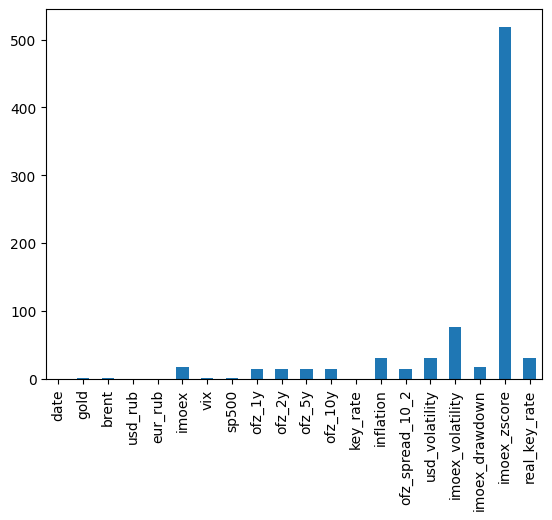

In [7]:
for col in df.columns:
    df.isna().sum().plot(kind='bar')